### ***Tourism Case Study***

#### ***Context***

***Analyze multidimensional tourism indicators to cluster countries and identify strategic investment opportunities for tourism services.***

#### ***Key Questions***

- *How many different groups/clusters of countries can be found from the data?*
- *How do the different clusters vary?*
- *How to use PCA to retain the components which explain variance of more than 40%?*
- *How to perform clustering using the components obtained from PCA?*

#### ***Data Description***

*This dataset contains key statistical indicators of the countries. It covers sections like general information, economic indicators, social indicators, environmental & infrastructural indicators.*
 
***Data Dictionary***
- `country`: country
- `Region`: region of the country
- `Surface area`: Surface area in sq. km
- `Population in thousands`: Population of the country, in thousands, as in the year 2017
- `Population density`: Population density per km2, as in the year 2017
- `GDP`: Gross domestic product: GDP of the country in million USD
- `Economy: Agriculture`: Contribution of agriculture to the economy as a percentage of Gross Value Added
- `Economy: Industry`: Contribution of the industry to the economy as a percentage of Gross Value Added
- `Economy: Services and other activity`: Contribution of services and other activities to the economy as a percentage of Gross Value Added
- `International trade: Balance: Amount`, in million USD, of balance between international exports and imports
- `Health: Total expenditure`: Total expenditure on healthcare facilities as a percentage of GDP
- `Education: Government expenditure`: Total expenditure on education as a percentage of GDP
- `Mobile-cellular subscriptions`: no. of mobile/cellular subscriptions per 100 people
- `Individuals using the Internet`: no. of individuals using the Internet per 100 people 
- `CO2 emission estimates`: CO2 emission estimates in million tons

#### ***Importing necessary libraries***

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import pdist

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# to perform PCA
from sklearn.decomposition import PCA

#### ***Dataset Load and Review***

In [2]:
# loading the dataset
data = pd.read_csv("data/41_country_stats.csv")

***View the random 10 rows of the dataset.***

In [3]:
# viewing a random sample of the dataset
data.sample(n=10, random_state=1)

,country,Region,Surface area,Population in thousands,Population density,GDP: Gross domestic product,Economy: Agriculture,Economy: Industry,Economy: Services and other activity,International trade: Balance,Health: Total expenditure,Education: Government expenditure,Mobile-cellular subscriptions,Individuals using the Internet
39,Central African Republic,MiddleAfrica,622984.0,4659,7.5,1633.0,34.9,24.8,40.4,66.0,4.2,1.2,20.4,60.0
170,Saint Kitts and Nevis,Caribbean,261.0,55,212.9,876.0,1.2,28.1,70.7,-280.0,5.1,2.8,131.8,52.0
93,Hungary,EasternEurope,93024.0,9722,107.4,121715.0,4.1,31.9,64.0,11027.0,7.4,4.7,118.9,66.0
62,Egypt,NorthernAfrica,1002000.0,97553,98.0,315917.0,11.2,36.3,52.5,-35545.0,5.6,NaN,111.0,156.0
199,Tajikistan,CentralAsia,142600.0,8921,63.7,7853.0,25.0,28.0,47.1,-2132.0,6.9,5.2,98.6,45.0
173,Saint Vincent and the Grenadines,Caribbean,389.0,110,281.8,738.0,7.5,17.2,75.3,-288.0,8.6,NaN,103.6,58.0
38,Cayman Islands,Caribbean,264.0,62,256.5,3726.0,0.3,7.5,92.2,-972.0,NaN,NaN,155.5,74.0
124,Mali,WesternAfrica,1240192.0,18542,15.2,13100.0,39.9,19.6,40.5,520.0,7.0,3.7,139.6,42.0
107,Kenya,EasternAfrica,591958.0,49700,87.3,63399.0,32.0,19.0,49.0,-8420.0,5.7,5.3,80.7,480.0
89,Guyana,SouthAmerica,214969.0,778,4.0,3282.0,17.6,31.7,50.6,-172.0,5.2,3.2,67.2,94.0


In [4]:
# checking the shape of the dataset
print(f'Dataset contains {data.shape[0]} rows and {data.shape[1]} columns.')

Dataset contains 229 rows and 14 columns.


In [5]:
# copying the data to another variable to avoid any changes to original data
df1 = data.copy()

***Check the data types of the columns for the dataset.***

In [6]:
# checking datatypes and number of non-null values for each column
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229 entries, 0 to 228
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   country                               229 non-null    object 
 1   Region                                229 non-null    object 
 2   Surface area                          226 non-null    float64
 3   Population in thousands               229 non-null    int64  
 4   Population density                    229 non-null    float64
 5   GDP: Gross domestic product           208 non-null    float64
 6   Economy: Agriculture                  206 non-null    float64
 7   Economy: Industry                     208 non-null    float64
 8   Economy: Services and other activity  208 non-null    float64
 9   International trade: Balance          210 non-null    float64
 10  Health: Total expenditure             190 non-null    float64
 11  Education: Governme

- ***Except for country and Region variables, remaining all the variables are numeric variables.***
- ***We can observe that there are missing values present in some of the variables.***

#### ***Statistical Summary***

In [7]:
# Let's look at the statistical summary of the data
df1.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,229,229,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,229,22,Caribbean,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Surface area,226.0,NaN,NaN,NaN,593210.044248,1796021.356287,0.00001,4306.5,83735.5,437693.5,17098246.0
Population in thousands,229.0,NaN,NaN,NaN,32756.79476,133275.079914,1.0,431.0,5448.0,19193.0,1409517.0
Population density,229.0,NaN,NaN,NaN,462.824891,2305.384253,0.1,35.9,88.1,222.8,25969.8
GDP: Gross domestic product,208.0,NaN,NaN,NaN,353896.341346,1548159.516063,33.0,4987.0,23871.0,174551.75,18036648.0
Economy: Agriculture,206.0,NaN,NaN,NaN,11.481553,12.100601,0.00001,2.4,7.2,17.5,70.8
Economy: Industry,208.0,NaN,NaN,NaN,27.565385,13.124423,4.0,19.075,26.45,33.325,79.9
Economy: Services and other activity,208.0,NaN,NaN,NaN,61.089423,15.50489,14.9,51.0,61.3,72.1,94.0
International trade: Balance,210.0,NaN,NaN,NaN,-683.861905,73188.172715,-796494.0,-3501.25,-984.0,49.25,530285.0


- ***There are 229 countries from 22 different regions.***
- ***Other features are describing the economic, Health, Education, Mobile Subscription of the population***

#### ***Exploratory Data Analysis***

***Univariate Analysis***

***Percentage of Countries by Region***

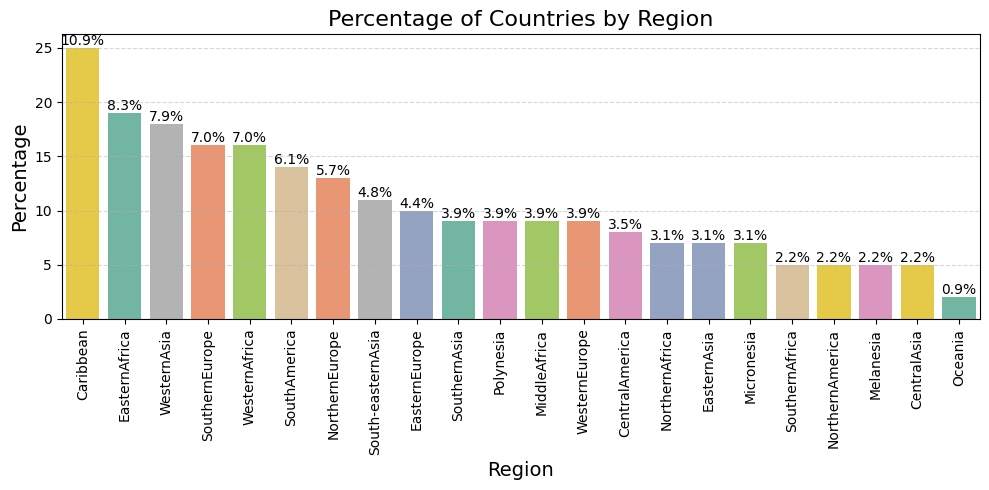

In [8]:
plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df1,
    x='Region',
    hue='Region',
    palette='Set2',
    order=df1['Region'].value_counts().index,
    legend=False
)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_title('Percentage of Countries by Region', fontsize=16)
ax.set_xlabel('Region', fontsize=14)
ax.set_ylabel('Percentage', fontsize=14)
ax.tick_params(axis='x', labelrotation=90)

total = len(df1)
for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f"{percentage:.1f}%", 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()


***Caribbean has highest number of Countries and Oceania has the least number of Countries***

***Helper Function to create Boxplot, Histogram and CDF plot***

In [9]:
# function to analyze a single numeric feature, creates boxplot, histogram, and CDF
def univariate_num_analysis_box_hist_cdf(data, feature, figsize=(8, 4)):
    """
    Display:
      - Left column: Boxplot (top) and Histogram (bottom)
      - Right column: CDF plot
    for a single numeric feature.
    
    Parameters:
    - data : pandas DataFrame
    - feature : str, numeric column name
    - figsize : tuple, figure size
    """
    fig = plt.figure(figsize=figsize)
    # Create grid: 2 rows, 2 columns
    grid = fig.add_gridspec(2, 2, width_ratios=(3, 2), height_ratios=(0.4, 1))

    # 1Boxplot (top left)
    ax_box = fig.add_subplot(grid[0, 0])
    sns.boxplot(data=data, x=feature, ax=ax_box, showmeans=True, color="lightgreen")
    ax_box.set_title(f'Boxplot of {feature}')

    # Histogram (bottom left)
    ax_hist = fig.add_subplot(grid[1, 0])
    sns.histplot(data=data, x=feature, kde=True, ax=ax_hist, color='skyblue')
    ax_hist.axvline(data[feature].mean(), color="green", linestyle="--", label="Mean")
    ax_hist.axvline(data[feature].median(), color="black", linestyle="-", label="Median")
    ax_hist.set_title(f'Histogram of {feature}')
    ax_hist.legend()

    # CDF Plot (right column, spans both rows)
    ax_cdf = fig.add_subplot(grid[:, 1])  # span both rows in column 2
    sns.ecdfplot(data=data, x=feature, ax=ax_cdf, color='orange')
    ax_cdf.set_title(f'CDF of {feature}')
    ax_cdf.set_ylabel("Cumulative Probability")
    ax_cdf.grid(True)

    plt.tight_layout()
    plt.show()

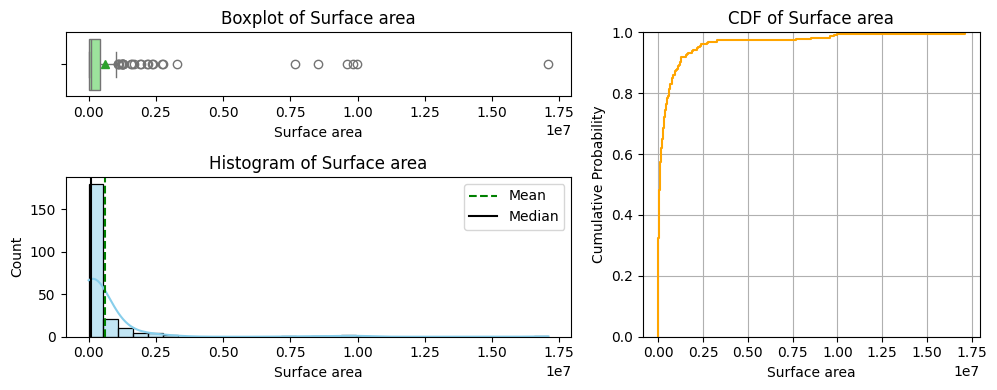

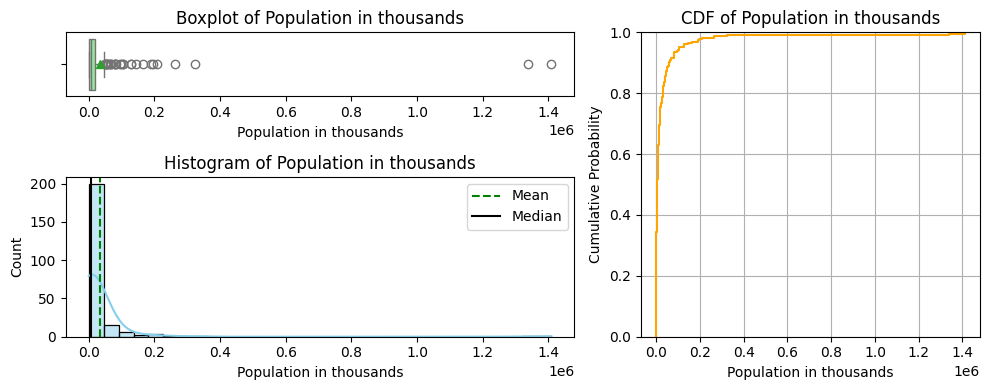

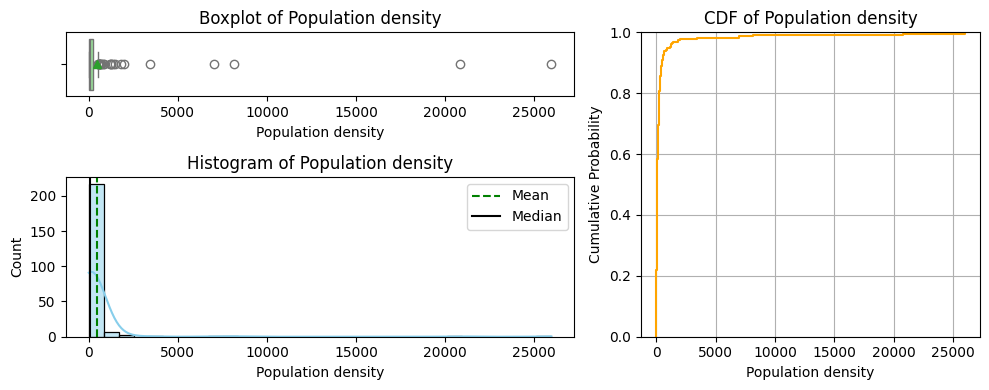

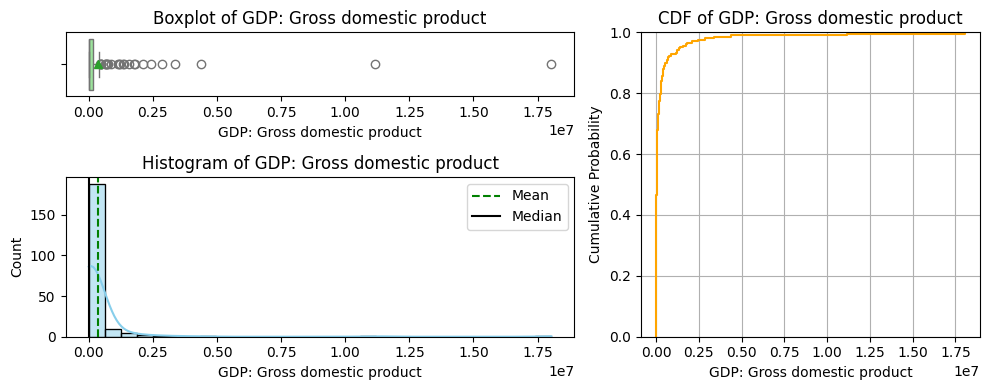

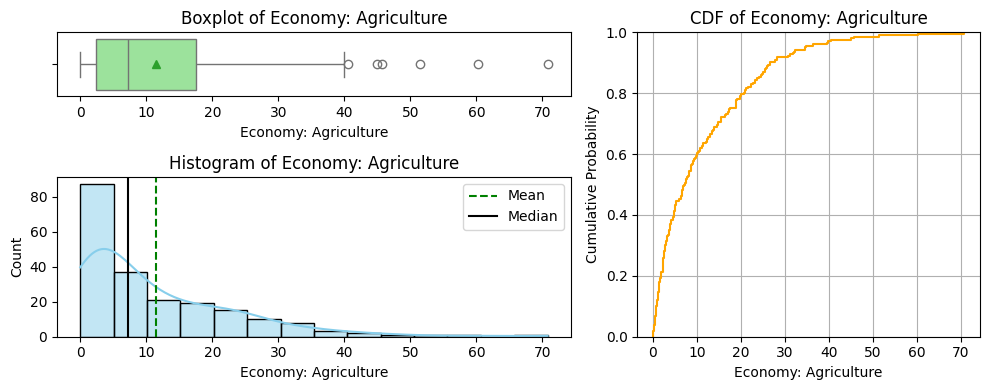

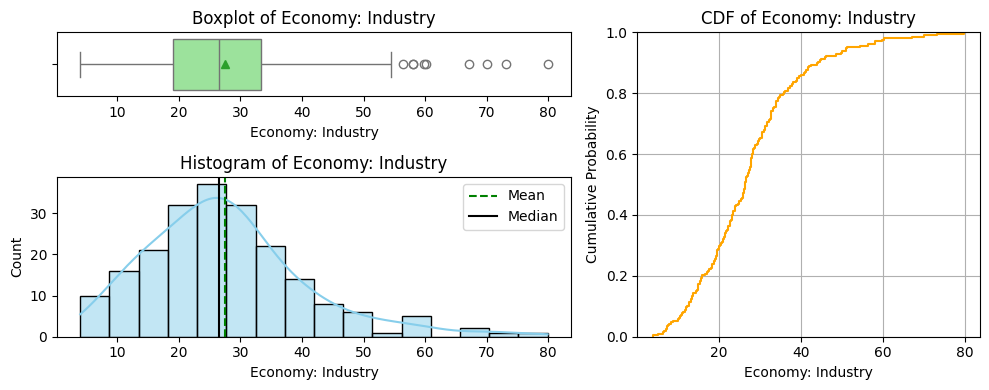

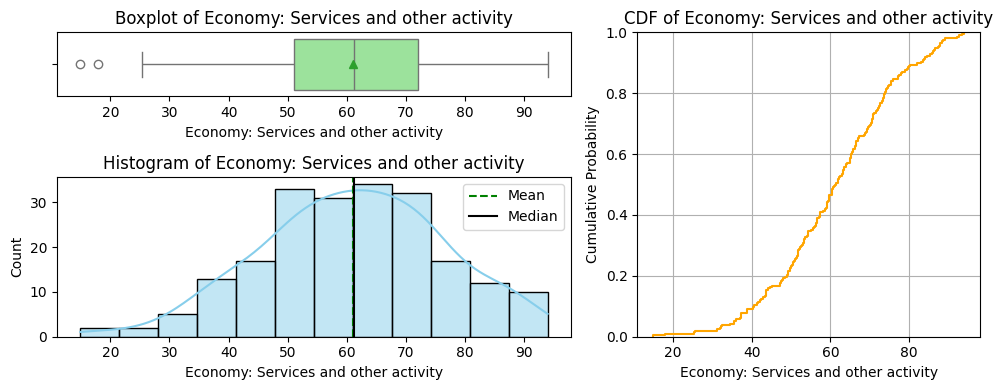

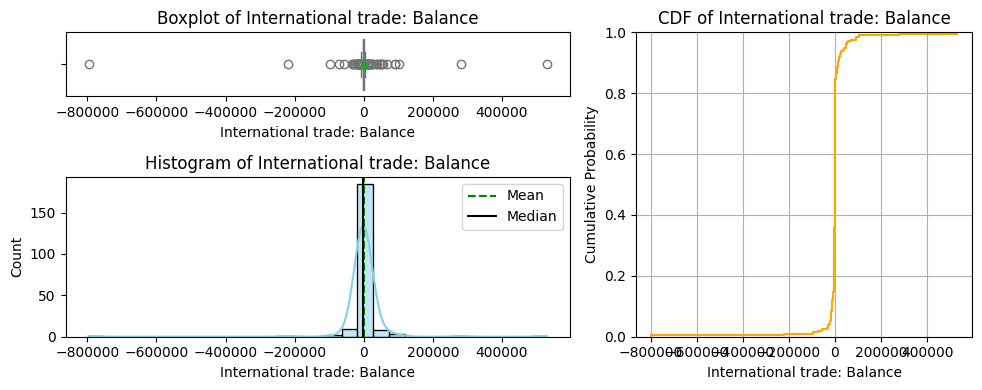

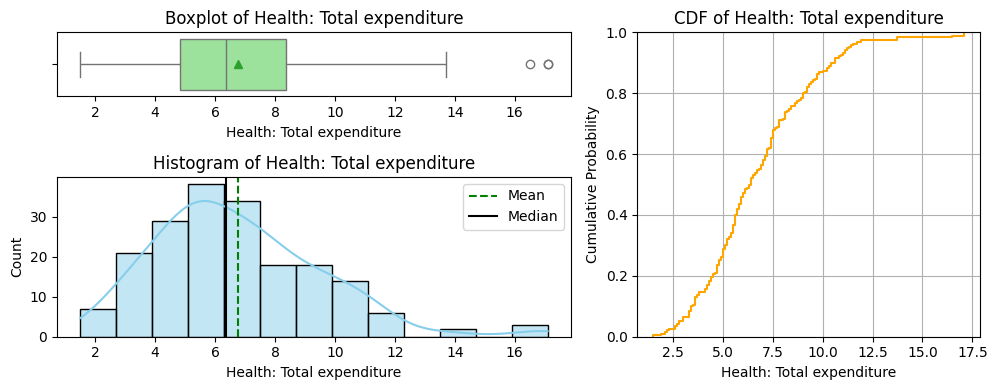

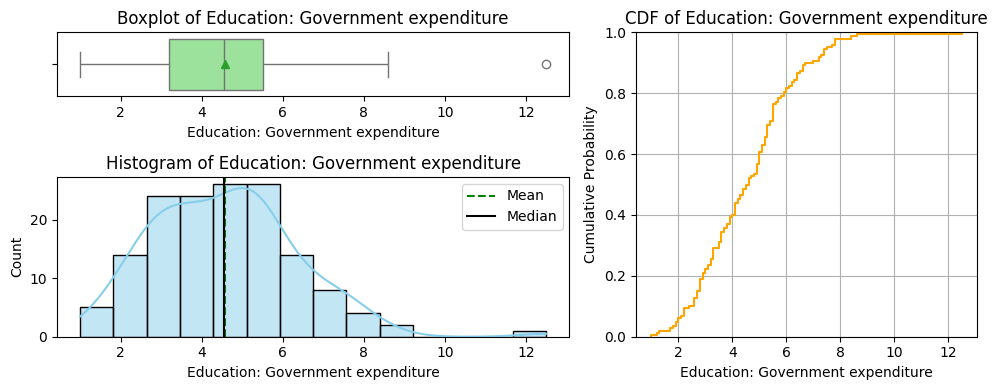

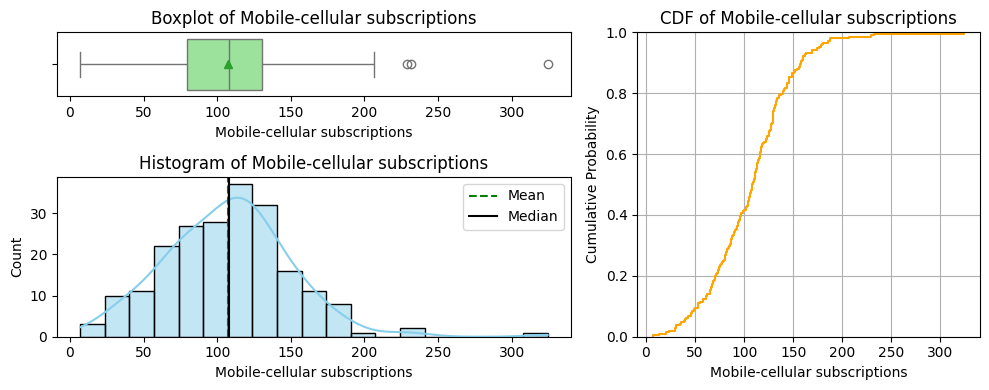

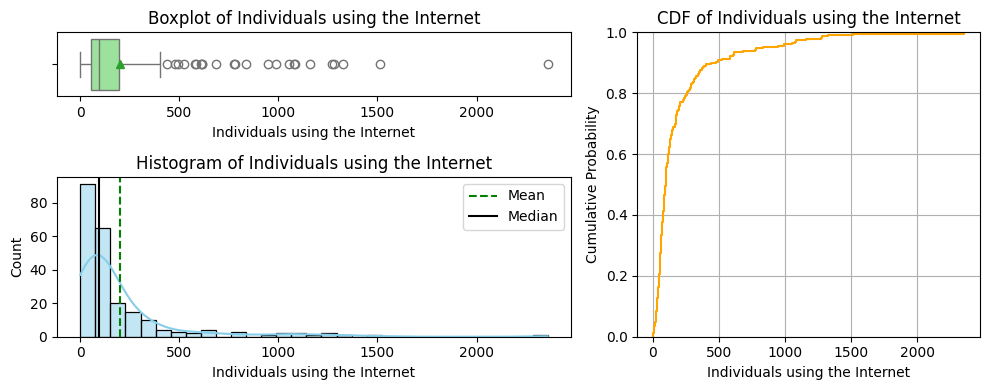

In [10]:
# selecting numerical columns
num_col = df1.select_dtypes(include=np.number).columns.tolist()

for item in num_col:
    univariate_num_analysis_box_hist_cdf(df1, item, figsize=(10, 4))

***Most of the features are Right Skewed and have outliers on the upper zone***

***Bivariate Analysis - Correlations***

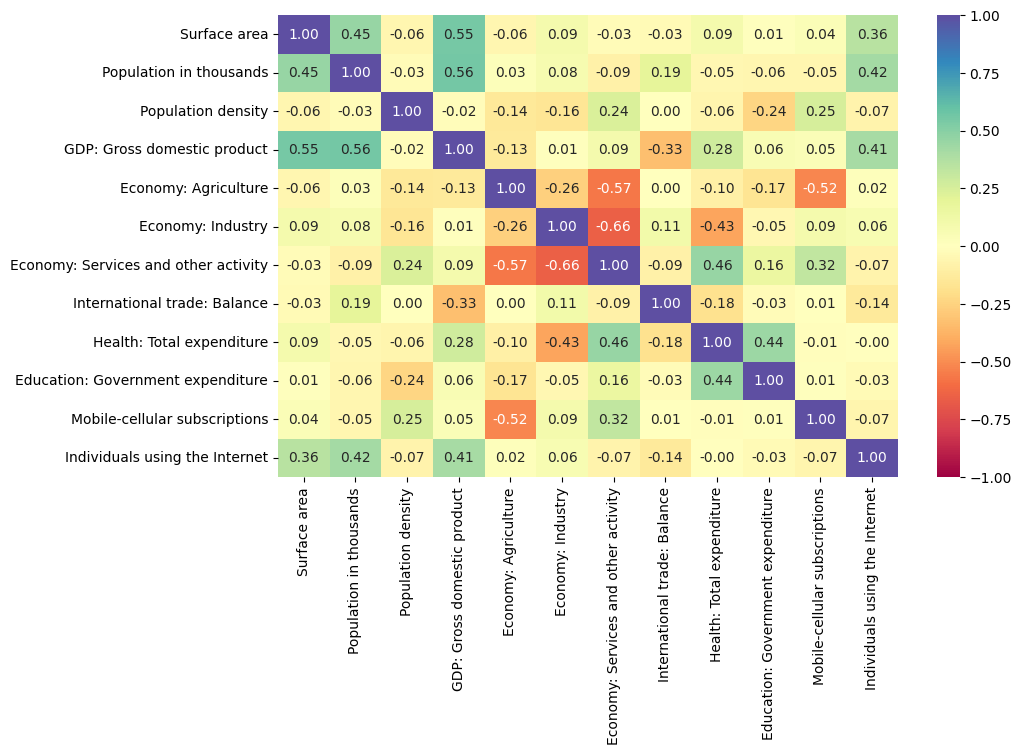

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    df1[num_col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

- *`Population in thousands` and `Surface Area` are positively correlated*
- *`GDP` and `Surface Area` are positively correlated* 
- *`Individuals using Internet` and and `Surface Area` are positively correlated*
- *`Economy: Services and other activity` are negatively correlated with `Agriculture` and `Industry`*
- *`Cellular Subscriptions` are negatively correlated to `Agriculture`*

#### ***Data Preprocessing***

***Checking for Null Values***

In [12]:
# checking for missing values

df1.isnull().sum().sort_values(ascending=False)

Education: Government expenditure       81
Health: Total expenditure               39
Economy: Agriculture                    23
GDP: Gross domestic product             21
Economy: Industry                       21
Economy: Services and other activity    21
Mobile-cellular subscriptions           20
International trade: Balance            19
Surface area                             3
Individuals using the Internet           1
country                                  0
Region                                   0
Population in thousands                  0
Population density                       0
dtype: int64

****How do impute the missing values?****
- *Since most of the numerical columns are right skewed so will use median grouped by region to impute*


In [13]:
for col in df1.iloc[:, 2:].columns.tolist():
    df1[col] = df1.groupby(["Region"])[col].transform(lambda x: x.fillna(x.median()))

# checking for missing values
df1.isna().sum()

country                                 0
Region                                  0
Surface area                            0
Population in thousands                 0
Population density                      0
GDP: Gross domestic product             0
Economy: Agriculture                    0
Economy: Industry                       0
Economy: Services and other activity    0
International trade: Balance            0
Health: Total expenditure               0
Education: Government expenditure       0
Mobile-cellular subscriptions           0
Individuals using the Internet          0
dtype: int64

***Feature Scaling - Standard Scaler***

In [14]:
# scaling the data using z-score

sc = StandardScaler()   # Initialize the StandardScaler
subset_scaled_df = pd.DataFrame(sc.fit_transform(df1.drop(["country", "Region"], axis=1)),columns=df1.drop(["country", "Region"], axis=1).columns,)

subset_scaled_df.head()

,Surface area,Population in thousands,Population density,GDP: Gross domestic product,Economy: Agriculture,Economy: Industry,Economy: Services and other activity,International trade: Balance,Health: Total expenditure,Education: Government expenditure,Mobile-cellular subscriptions,Individuals using the Internet
0,0.035310,0.020854,-0.177549,-0.210173,1.042856,-0.274480,-0.553324,-0.022866,0.477955,-0.768586,-1.047607,-0.532544
1,-0.315158,-0.224289,-0.154727,-0.216092,0.966043,-0.064870,-0.659127,-0.031399,-0.364263,-0.669595,0.012310,-0.234595
2,1.006147,0.064378,-0.193677,-0.112187,0.095503,0.812389,-0.738478,-0.237101,0.111773,0.716281,0.168458,-0.217666
3,-0.331189,-0.245901,-0.080260,-0.223645,-0.152004,-1.159503,0.326156,0.006091,0.111773,-0.471613,-1.036960,-0.363255
4,-0.331038,-0.245743,-0.129991,-0.222011,-0.903058,-1.244900,1.780935,-0.010646,0.441337,-0.768586,-0.420647,-0.630731


#### ***Cophenetic Correlation***

***Let's find the Cophenetic correlation for different distances with different linkage methods.***

***What is Cophenetic correlation?*** 

***Find best combination of distance metrics and linkage method for hierarchical cluster - the one that yieids the highest cophenetic correlation coefficient***

In [15]:
# list of distance metrics
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(subset_scaled_df, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(subset_scaled_df))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm
    print() # just to add a new line after each distance metric

Cophenetic correlation for Euclidean distance and single linkage is 0.9155400692823865.
Cophenetic correlation for Euclidean distance and complete linkage is 0.7825108242995893.
Cophenetic correlation for Euclidean distance and average linkage is 0.9346981702379012.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8344399530606007.

Cophenetic correlation for Chebyshev distance and single linkage is 0.909597369962777.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.8421171787471619.
Cophenetic correlation for Chebyshev distance and average linkage is 0.9141365131195623.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.8792996800400402.

Cophenetic correlation for Mahalanobis distance and single linkage is 0.8449434742316895.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.7845772349957594.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.8729332119700157.
Cophenetic c

In [16]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.9346981702379012, which is obtained with Euclidean distance and average linkage.


***Let's explore different linkage methods with Euclidean distance only.***

In [17]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for lm in linkage_methods:
    Z = linkage(subset_scaled_df, metric="euclidean", method=lm)
    c, coph_dists = cophenet(Z, pdist(subset_scaled_df))
    print("Cophenetic correlation for {} linkage is {}.".format(lm, c))
    if high_cophenet_corr < c:
        high_cophenet_corr = c
        high_dm_lm[0] = "euclidean"
        high_dm_lm[1] = lm

Cophenetic correlation for single linkage is 0.9155400692823865.
Cophenetic correlation for complete linkage is 0.7825108242995893.
Cophenetic correlation for average linkage is 0.9346981702379012.
Cophenetic correlation for centroid linkage is 0.9484608827294535.
Cophenetic correlation for ward linkage is 0.4666407735353128.
Cophenetic correlation for weighted linkage is 0.8344399530606007.


In [18]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} linkage.".format(
        high_cophenet_corr, high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.9484608827294535, which is obtained with centroid linkage.


***We see that the cophenetic correlation is maximum with Euclidean distance and centroid linkage.***

#### ***Dendrograms***

***Let's see the dendrograms for the different linkage methods.***

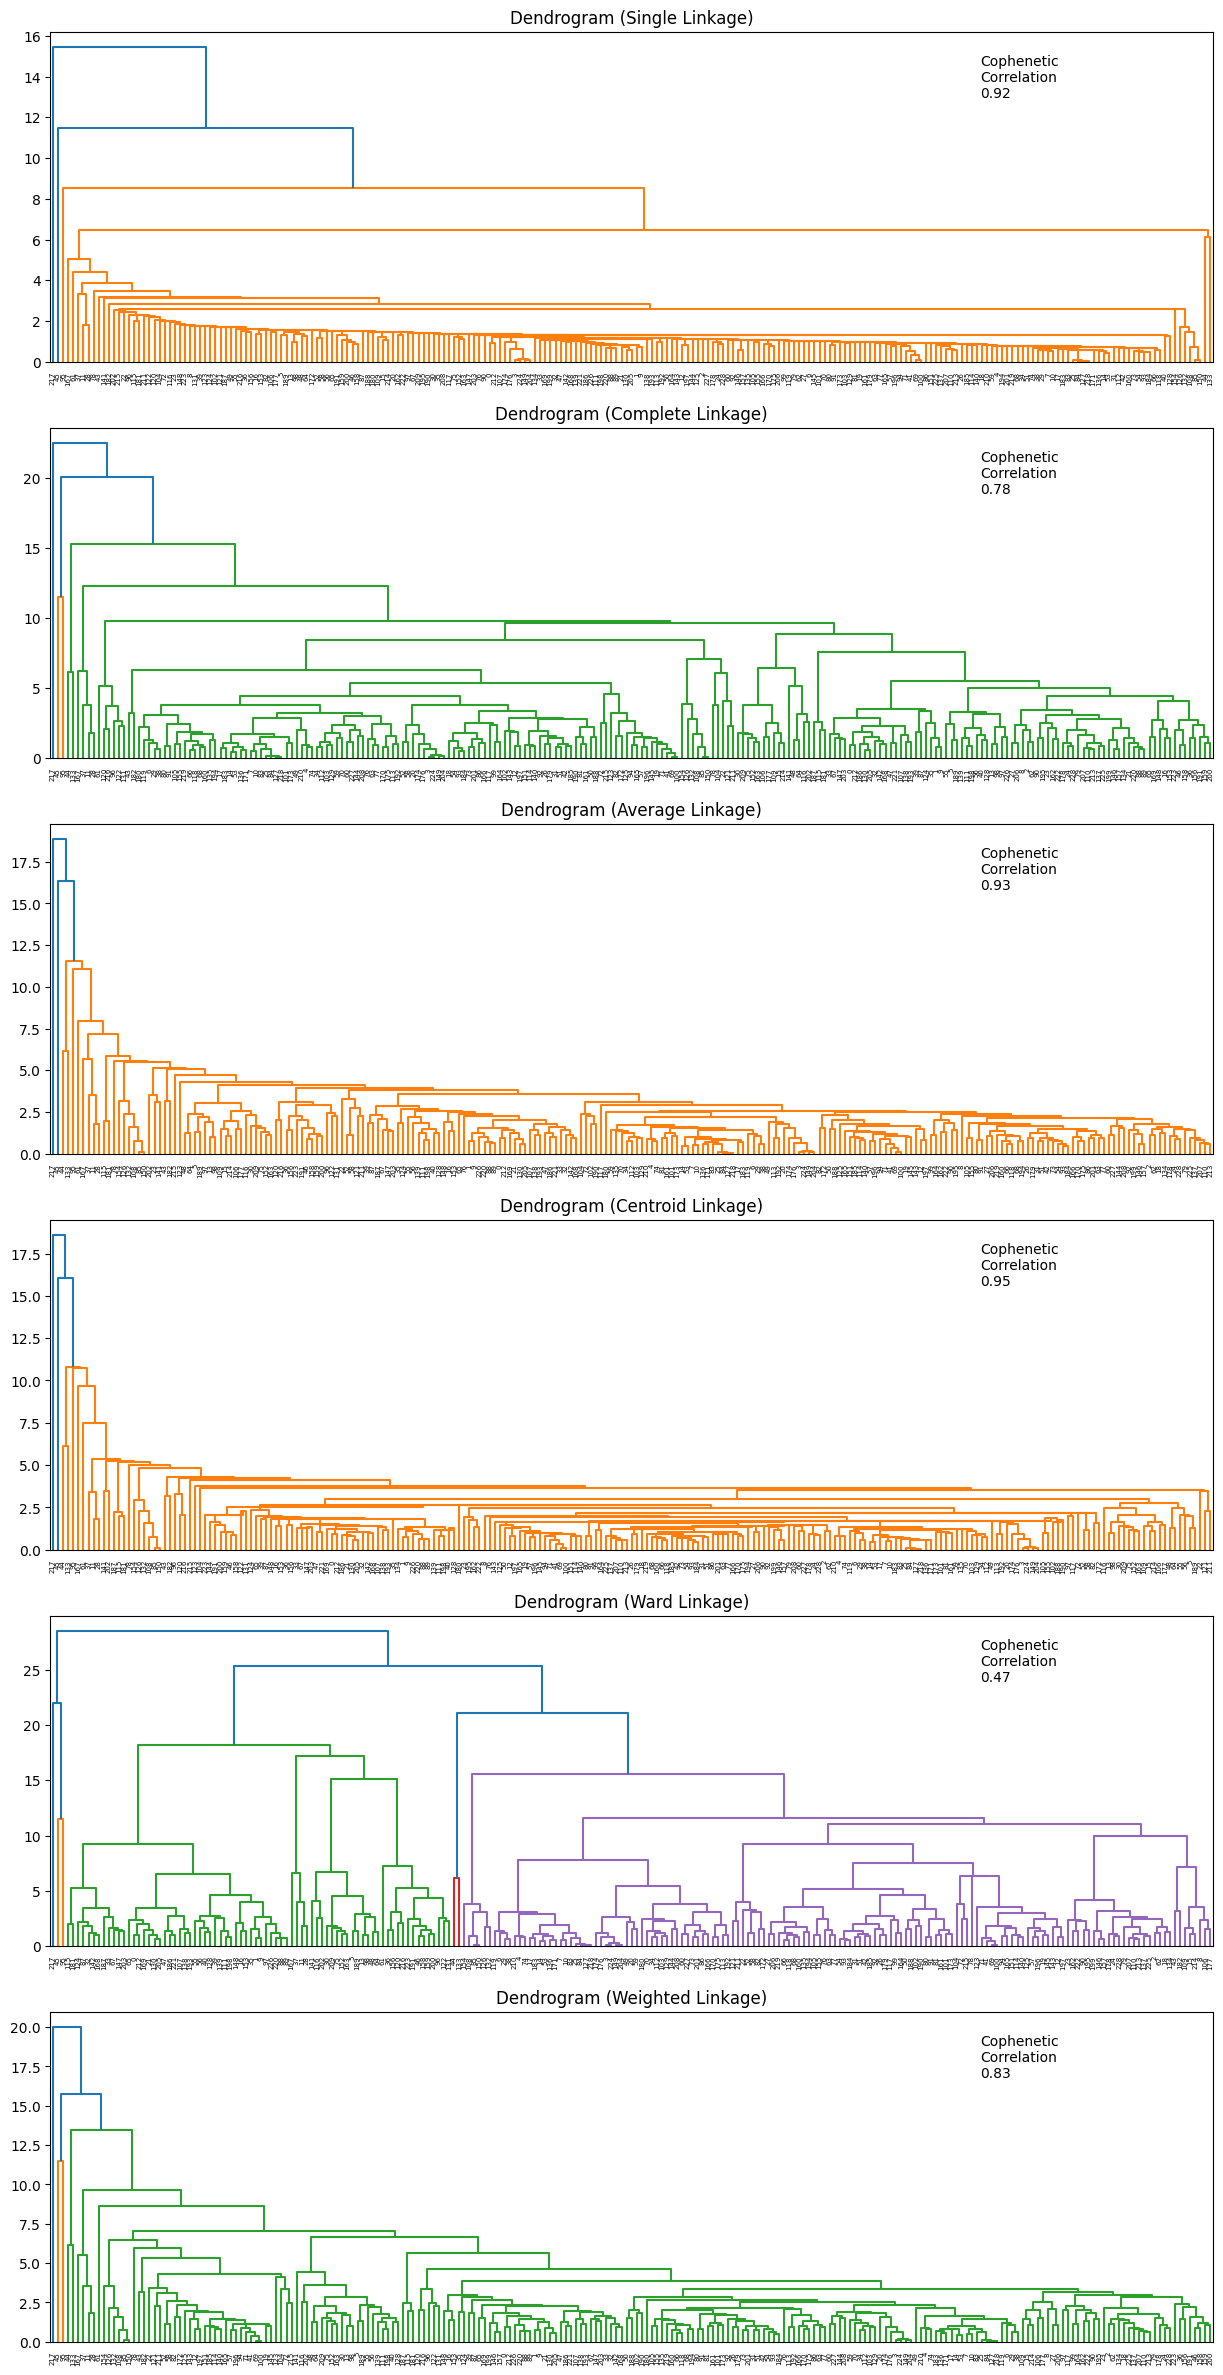

In [19]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(subset_scaled_df, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(subset_scaled_df))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

- ***The cophenetic correlation is highest for average and centroid linkage methods. We will move ahead with Centroid linkage.***
- ***6 appears to be the appropriate number of clusters from the dendrogram for Centroid linkage.***

***The optimal number of clusters from a dendrogram can be obtained by deciding where to cut the cluster tree. Generally, the cluster tree is cut where dendrogram height is maximum as it generally corresponds to distinct and homogeneous clusters.***

***The dendrogram for centroid linkage had the highest cophenetic correlation. So we can use centroid linkage and have chosen 6 clusters as the dendrogram height is pretty high. (The maximum height is for 3, but that would not be meaningful as it would give two clusters with one country each and one cluster will all the other countries).***

***Lets visualize the dendrogram cut for average link in the below plot***

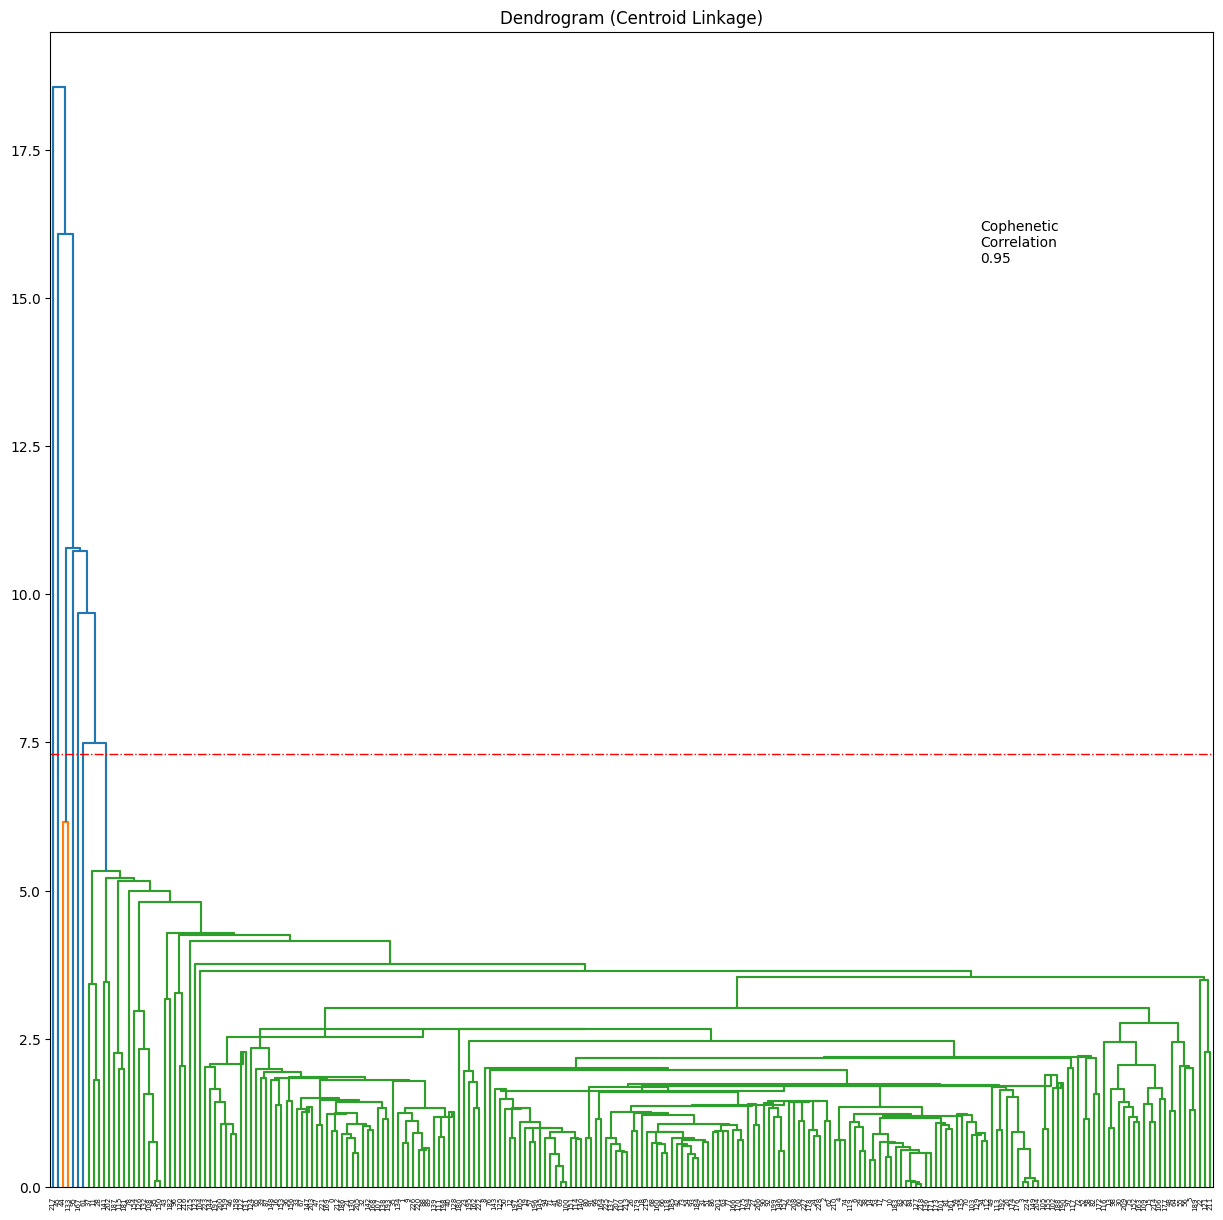

In [20]:
# list of linkage methods
linkage_methods = ["centroid"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 15))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(subset_scaled_df, metric="euclidean", method=method)

    dendrogram(Z, ax=axs)
    axs.set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(subset_scaled_df))
    axs.annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )
dendrogram(Z, color_threshold=7.3)
plt.axhline(y=7.3, c="red", lw=1, linestyle="dashdot")

#### ***Hierarchical Clustering***

In [21]:
HCmodel = AgglomerativeClustering(n_clusters=6, metric="euclidean", linkage="average")
HCmodel.fit(subset_scaled_df)

,n_clusters,6
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'average'
,distance_threshold,None
,compute_distances,False


In [22]:
subset_scaled_df["HC_Clusters"] = HCmodel.labels_
df1["HC_Clusters"] = HCmodel.labels_

#### ***Cluster Profiling `1`***

In [23]:
cluster_profile = df1.select_dtypes(include=[np.number]).groupby("HC_Clusters").mean()

In [24]:
cluster_profile["count_in_each_segments"] = (
    df1.groupby("HC_Clusters")["Surface area"].count().values
)

In [25]:
# let's see the names of the countries in each cluster
for cl in df1["HC_Clusters"].unique():
    print("In cluster {}, the following countries are present:".format(cl))
    print(df1[df1["HC_Clusters"] == cl]["country"].unique())
    print()

In cluster 0, the following countries are present:
['Afghanistan' 'Albania' 'Algeria' 'American Samoa' 'Andorra' 'Angola'
 'Anguilla' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan'
 'Bolivia (Plurinational State of)' 'Bonaire, Sint Eustatius and Saba'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'British Virgin Islands'
 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde'
 'Cambodia' 'Cameroon' 'Canada' 'Cayman Islands'
 'Central African Republic' 'Chad' 'Channel Islands' 'Chile'
 'China, Hong Kong SAR' 'Colombia' 'Comoros' 'Congo' 'Cook Islands'
 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czechia'
 "Democratic People's Republic of Korea"
 'Democratic Republic of the Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'Egypt' 'El Salvador' 'Equatorial Guinea' 'Eritrea'
 'Estonia' 'Ethiopia' 'Falkland Islands (Malvinas)' 'F

*****Note:** **China** and **China, Macao SAR** are two different countries in the dataset.***

**We see that there are 4 clusters of one country, 1 cluster of three countries, and all the other countries are grouped into another cluster. This clustering does not look good as the clusters do not have enough variability.**

***On checking the cluster profiles, it's found centroid linkage still does not give proper clustering as 5 clusters have one or two countries in them. On checking the dendrogram for different linkages further, the Ward linkage gives us homogeneous clusters, with more variability between clusters, despite a low cophenetic correlation. Let us try using Ward linkage as it has more distinct and separated clusters (as seen from its dendrogram before). 6 appears to be the appropriate number of clusters from the dendrogram for Ward linkage.***

**Lets visualize the dendrogram cut for ward linkage in the below plot**

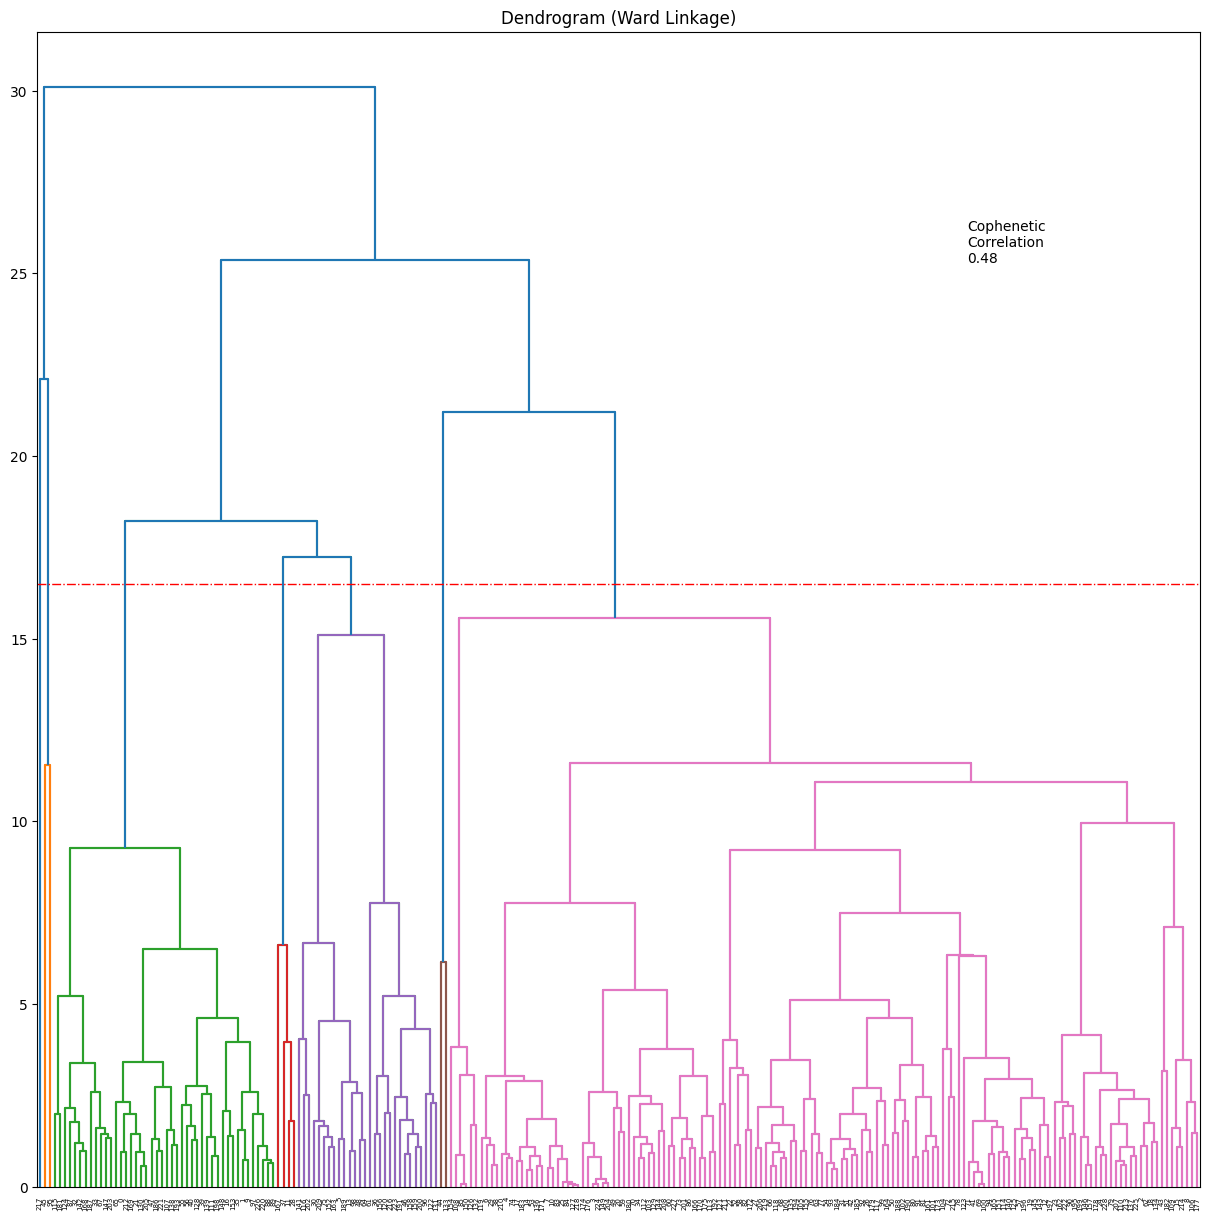

In [26]:
# list of linkage methods
linkage_methods = ["ward"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 15))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(subset_scaled_df, metric="euclidean", method=method)

    dendrogram(Z, ax=axs)
    axs.set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(subset_scaled_df))
    axs.annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )
dendrogram(Z, color_threshold=16.5)
plt.axhline(y=16.5, c="red", lw=1, linestyle="dashdot")

In [27]:
HCmodel = AgglomerativeClustering(n_clusters=6, metric="euclidean", linkage="ward")
HCmodel.fit(subset_scaled_df)

,n_clusters,6
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [28]:
subset_scaled_df["HC_Clusters"] = HCmodel.labels_
df1["HC_Clusters"] = HCmodel.labels_

#### ***Cluster Profiling `2`***

In [29]:
cluster_profile = df1.select_dtypes(include=[np.number]).groupby("HC_Clusters").mean()

In [30]:
cluster_profile["count_in_each_segments"] = (
    df1.groupby("HC_Clusters")["Surface area"].count().values
)

In [31]:
# let's see the names of the countries in each cluster
for cl in df1["HC_Clusters"].unique():
    print(
        "The",
        df1[df1["HC_Clusters"] == cl]["country"].nunique(),
        "countries in cluster",
        cl,
        "are:",
    )
    print(df1[df1["HC_Clusters"] == cl]["country"].unique())
    print("-" * 100, "\n")

The 44 countries in cluster 5 are:
['Afghanistan' 'Albania' 'Armenia' 'Bangladesh' 'Benin' 'Burkina Faso'
 'Burundi' 'Cambodia' 'Central African Republic' 'Chad' 'Comoros'
 "Democratic People's Republic of Korea"
 'Democratic Republic of the Congo' 'Eritrea' 'Ethiopia' 'Guinea-Bissau'
 'Guinea' 'Guyana' 'Iran (Islamic Republic of)' 'Kenya'
 "Lao People's Democratic Republic" 'Liberia' 'Mali' 'Mauritania'
 'Mayotte' 'Mozambique' 'Myanmar' 'Nepal' 'Niger' 'Nigeria' 'Pakistan'
 'Rwanda' 'Saint Helena' 'Sierra Leone' 'Solomon Islands' 'Somalia'
 'Sudan' 'Syrian Arab Republic' 'Togo' 'Tonga' 'Uganda' 'Uzbekistan'
 'Vanuatu' 'Yemen']
---------------------------------------------------------------------------------------------------- 

The 148 countries in cluster 2 are:
['Algeria' 'American Samoa' 'Andorra' 'Anguilla' 'Antigua and Barbuda'
 'Argentina' 'Aruba' 'Austria' 'Bahamas' 'Bahrain' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Bermuda' 'Bhutan' 'Bolivia (Plurinational State of)'
 'Bonair

***Now the clusters seem to have more variability.***

In [32]:
# lets display cluster profile
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Surface area,Population in thousands,Population density,GDP: Gross domestic product,Economy: Agriculture,Economy: Industry,Economy: Services and other activity,International trade: Balance,Health: Total expenditure,Education: Government expenditure,Mobile-cellular subscriptions,Individuals using the Internet,count_in_each_segments
HC_Clusters,,,,,,,,,,,,,
0,1857323.781250,45709.656250,97.065625,329348.031250,8.393750,43.871875,47.746875,4106.187500,4.906250,4.314063,107.571875,551.812500,32
1,6443631.500000,1374348.500000,300.250000,6637348.000000,13.100000,35.400000,51.450000,216953.500000,5.100000,3.700000,86.000000,1066.000000,2
2,220764.489865,10516.020270,331.800676,213967.959459,6.521284,24.186149,68.686149,915.722973,7.706081,5.362162,115.291216,120.317568,148
3,9833517.000000,324460.000000,35.500000,18036648.000000,1.000000,19.700000,79.300000,-796494.000000,17.100000,5.400000,117.600000,1513.000000,1
4,16.000000,331.000000,23395.700000,26218.000000,3.225000,10.000000,90.000000,8826.500000,5.375000,1.500000,206.600000,16.000000,2
5,460865.261364,32009.250000,144.247727,46650.704545,28.867045,23.895455,46.960227,-882.261364,5.530682,3.723864,69.051136,147.613636,44


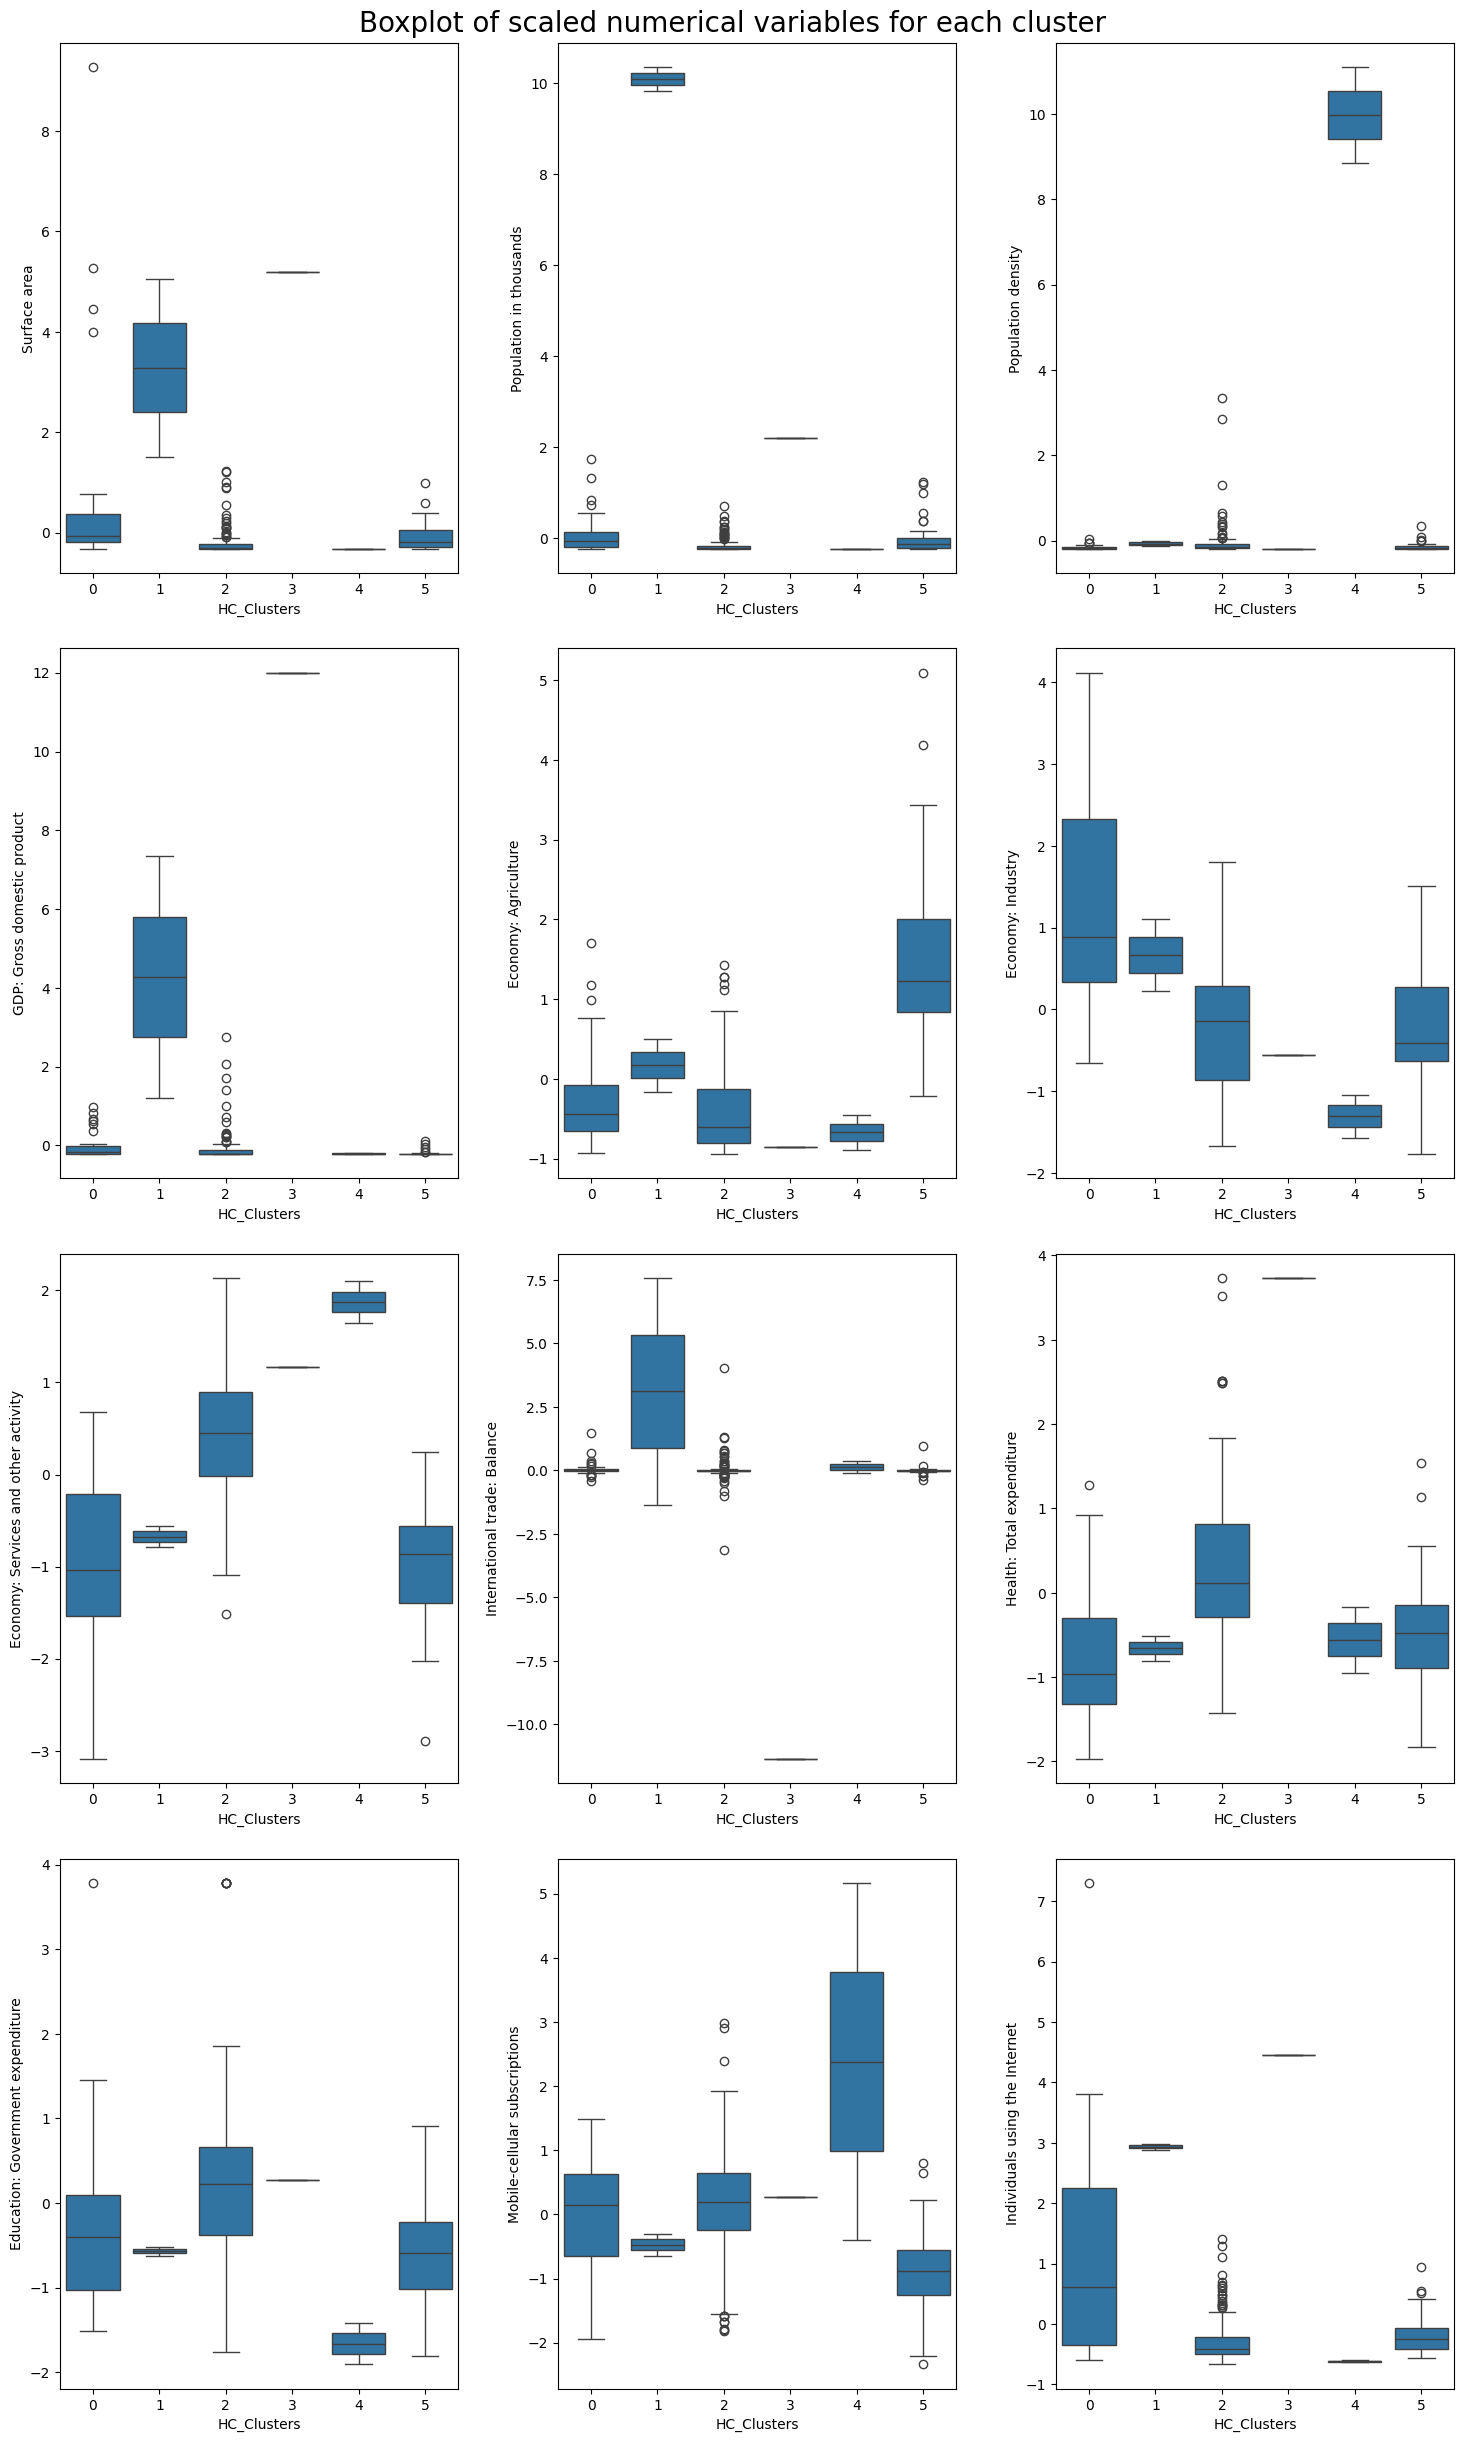

In [33]:
fig, axes = plt.subplots(4, 3, figsize=(15, 25))
fig.suptitle("Boxplot of scaled numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(4):
    sns.boxplot(
        ax=axes[ii][0],
        y=subset_scaled_df[num_col[counter]],
        x=subset_scaled_df["HC_Clusters"],
    )
    counter = counter + 1
    sns.boxplot(
        ax=axes[ii][1],
        y=subset_scaled_df[num_col[counter]],
        x=subset_scaled_df["HC_Clusters"],
    )
    counter = counter + 1
    sns.boxplot(
        ax=axes[ii][2],
        y=subset_scaled_df[num_col[counter]],
        x=subset_scaled_df["HC_Clusters"],
    )
    counter = counter + 1


fig.tight_layout(pad=2.0)

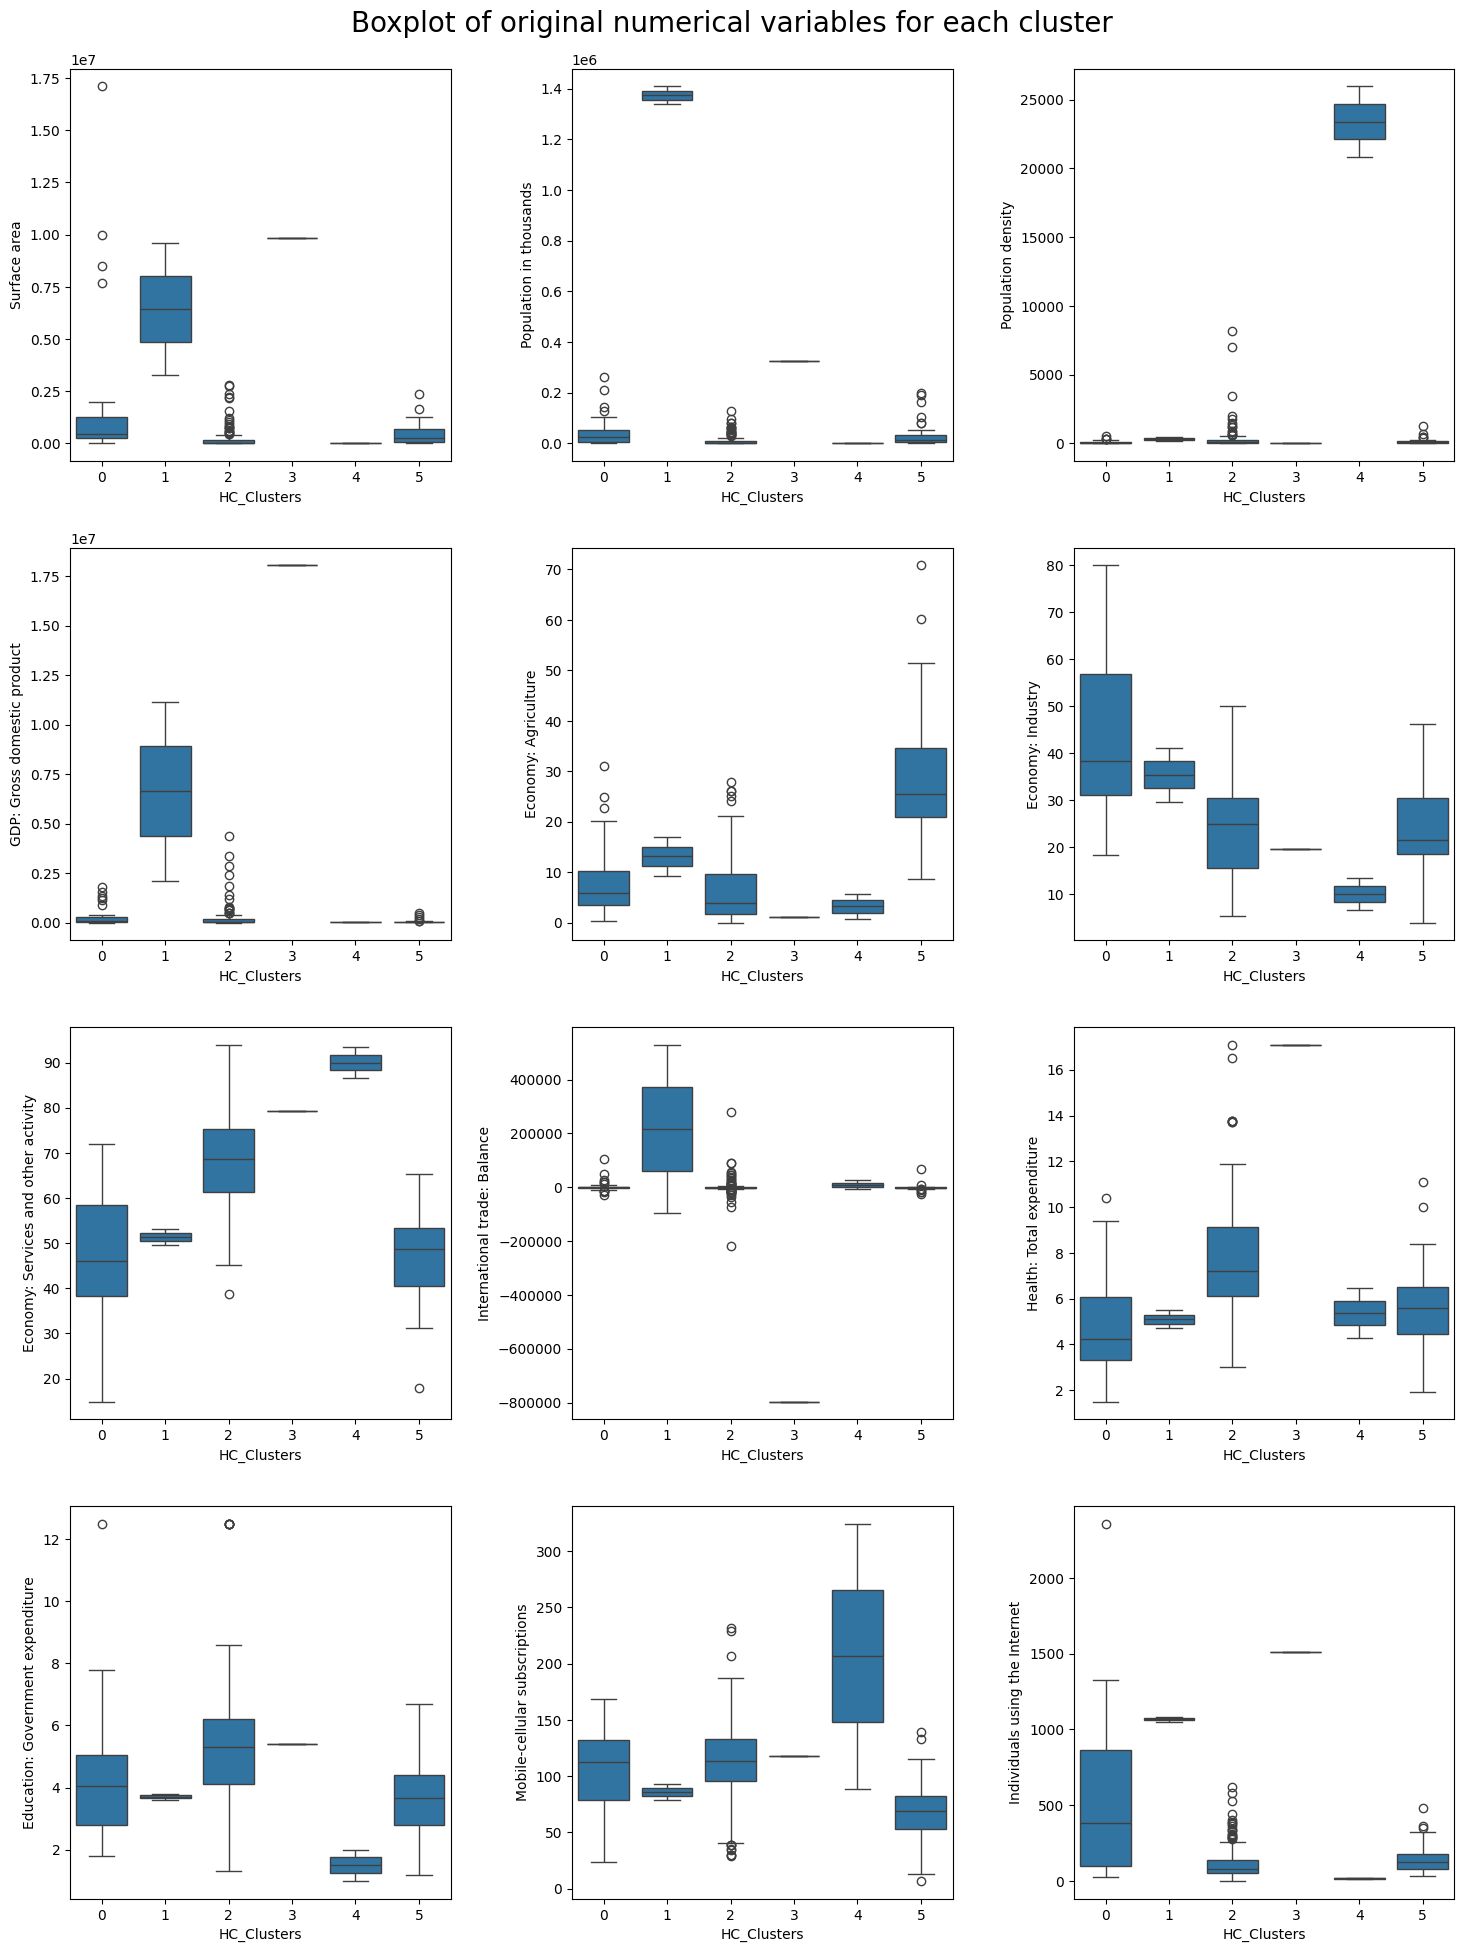

In [34]:
fig, axes = plt.subplots(4, 3, figsize=(15, 20))
fig.suptitle("Boxplot of original numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(4):
    sns.boxplot(ax=axes[ii][0], y=df1[num_col[counter]], x=df1["HC_Clusters"])
    counter = counter + 1
    sns.boxplot(ax=axes[ii][1], y=df1[num_col[counter]], x=df1["HC_Clusters"])
    counter = counter + 1
    sns.boxplot(ax=axes[ii][2], y=df1[num_col[counter]], x=df1["HC_Clusters"])
    counter = counter + 1


fig.tight_layout(pad=2.0)

#### ***Insights***

***We will look into clusters 0, 2, and 5 only because the other clusters have only 1 or 2 countries in them.***

***Cluster 0***
- *There are 32 countries in this cluster.*
- *The number of individuals using the internet is moderate and mobile subscribers are moderate.*
- *Expenditure on health is low to moderate and that on education is also low to moderate.*
- *GDP is low, but the economy in healthy and balanced across agriculture, industry, services, and other activities are high*
   
   
***Cluster 2***
- *There are 148 countries in this cluster.*
- *The number of individuals using the internet is high but mobile subscribers are moderate.*
- *Expenditure on health is moderate and that on education is also moderate.*
- *GDP is moderate and economy is moderately healthy with a slightly high dependence on services and other activities.*
   
   
***Cluster 5***
- *There are 44 countries in this cluster.*
- *The number of individuals using the internet are moderate and mobile subscribers are also moderate.*
- *Expenditure on health is moderate and that on education is low.*
- *GDP is moderate and economy is moderately healthy with a slightly high dependence on services and other activities.*


***Recommendations***

***Cluster 5 countries are good places to provide tourism services based on cluster profiling done above.***